In [1]:
import pandas as pd
import numpy as np

# Step 1: Load CSV files
def load_csv(file_path):
    """Load a CSV file into a DataFrame."""
    return pd.read_csv(file_path)

# Step 1: Load CSV files
def load_mapping(file_path):
    """Load a .p file into a DataFrame."""
    return pd.read_pickle(file_path)

# Step 3: Prepare triple processing
def process_triples(triples, entity_vectors, relation_vectors):
    """Concatenate entity, relation, and entity vectors for each triple."""
    concatenated_vectors = []
    relation_labels = []
    for triple in triples:
        entity1_idx, relation_idx, entity2_idx = triple

        # Retrieve vectors
        entity1_vector = entity_vectors[entity1_idx]
        relation_vector = relation_vectors[relation_idx]
        entity2_vector = entity_vectors[entity2_idx]

        # Concatenate vectors
        relation_labels.append(relation_idx)
        concatenated_vector = np.concatenate([entity1_vector, relation_vector, entity2_vector])
        concatenated_vectors.append(concatenated_vector)

    return np.array(concatenated_vectors), np.array(relation_labels)

def get_concat_vectors(pqr):
    entities_file = f"./KGs_Family_family-benchmark_rich_background_owl_{pqr}/DeCaL_entity_embeddings.csv"
    # relations_file = f"./KGs_Family_family-benchmark_rich_background_owl_{pqr}/DeCaL_relation_embeddings.csv"
    entity_map_file = f"./KGs_Family_family-benchmark_rich_background_owl_{pqr}/entity_to_idx.p"
    # relation_map_file = f"./KGs_Family_family-benchmark_rich_background_owl_{pqr}/relation_to_idx.p"
    
    # Load data
    entities_df = load_csv(entities_file)
    relations_df = load_csv(relations_file)
    entity_map = load_mapping(entity_map_file)
    relation_map = load_mapping(relation_map_file)
    
    # Convert entity and relation vectors to numpy arrays
    entity_vectors = entities_df.iloc[:, 1:].to_numpy()  # Assuming vectors start from column 1
    relation_vectors = relations_df.iloc[:, 1:].to_numpy()  # Assuming vectors start from column 1
    
    # Example triples
    # files = 'test'
    triples = np.load(f'./KGs_Family_family-benchmark_rich_background_owl_{pqr}/train_set.npy')
    
    # Process triples
    vectors, labsq = process_triples(triples, entity_vectors, relation_vectors)
    return vectors, labsq

In [10]:
vec,labs = get_concat_vectors("0_0_0")

In [11]:
vec.shape


(4064, 96)

In [12]:
import umap

f = umap.UMAP(n_neighbors=5, random_state=42).fit(vec)

f_mapped = f.transform(vec)


/home/iroberts/miniconda3/envs/concepts_pb_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/iroberts/miniconda3/envs/concepts_pb_bi/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/iroberts/miniconda3/envs/concepts_pb_bi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


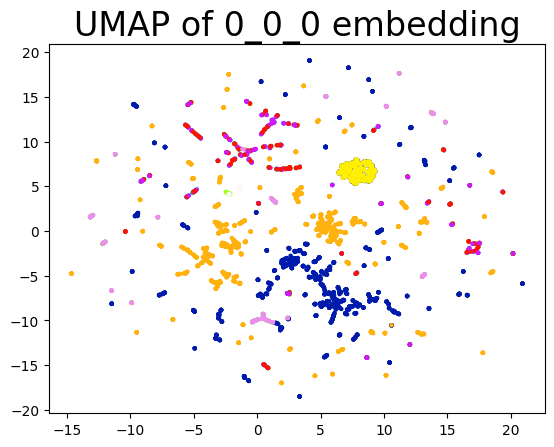

In [15]:
import matplotlib.pyplot as plt
plt.scatter(f_mapped[:, 0], f_mapped[:, 1], s=5, c=labs, cmap='gist_ncar')
plt.title('UMAP of 0_0_0 embedding', fontsize=24);